In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import multiprocessing
from functools import partial

np.random.seed(42)

In [119]:
class MWUAgent:
    def __init__(self, num_bids):
        self.num_bids = num_bids
        self.weights = np.ones(num_bids)

    def get_strategy(self):
        return self.weights / np.sum(self.weights)

    def update(self, utilities, eta):
        shifted_u = utilities - np.max(utilities)
        self.weights = self.weights * np.exp(eta * shifted_u)

class NoSwapRegretAgent:
    def __init__(self, num_bids):
        self.num_bids = num_bids
        # Store all expert weights as a single 2D array instead of a list of MWUAgents
        # weights[j] corresponds to the weight vector of expert j
        self.weights = np.ones((num_bids, num_bids))
        self.last_q = np.ones(num_bids) / num_bids

    def get_strategy(self):
        P = self.weights / self.weights.sum(axis=1, keepdims=True)
        q = self.last_q.copy()
        for _ in range(500):
            q_new = q @ P
            if np.max(np.abs(q_new - q)) < 1e-12:
                break
            q = q_new
        q = np.maximum(q_new, 0)
        q_sum = q.sum()
        q = q / q_sum if q_sum > 0 else np.ones(self.num_bids) / self.num_bids

        self.last_q = q
        return q

    def update(self, utilities, eta):
        shifted_u = utilities - np.max(utilities)
        self.weights *= np.exp(eta * np.outer(self.last_q, shifted_u))

def simulate_auction(v1, v2, V, learning_rates, auction_type='first', algo1='MWU', algo2='MWU', verbose=1, every=10000, learning_rates_2=None):
    bids = np.array([i / V for i in range(1, V + 1)])
    num_bids = len(bids)

    agent1 = MWUAgent(num_bids) if algo1 == 'MWU' else NoSwapRegretAgent(num_bids)
    agent2 = MWUAgent(num_bids) if algo2 == 'MWU' else NoSwapRegretAgent(num_bids)

    history = {
        'round': [], 'winner': [], 'winning_bid': [], 'payment': [],
        'bid1': [], 'bid2': [],
        'external_regret1': [], 'external_regret2': [],
        'swap_regret1': [],    'swap_regret2': []
    }

    # Running sums — updated every round, never recomputed from scratch
    cum_u1 = np.zeros(num_bids)          # Σ_t u1[b] for each fixed bid b
    cum_u2 = np.zeros(num_bids)
    cum_actual_u1 = 0.0                  # Σ_t u1[b1_t] (utility actually received)
    cum_actual_u2 = 0.0
    # swap_u[a, b] = Σ_{t: b_t=a} u[b]  (counterfactual utility of b on rounds a was played)
    swap_u1 = np.zeros((num_bids, num_bids))
    swap_u2 = np.zeros((num_bids, num_bids))

    for t, eta in enumerate(learning_rates):
        if t % every == 0 and verbose:
            print(f"Round {t}")

        p1 = agent1.get_strategy()
        p2 = agent2.get_strategy()

        b1 = np.random.choice(bids, p=p1)
        b2 = np.random.choice(bids, p=p2)

        # Index of the chosen bid in the bids array
        idx1 = np.searchsorted(bids, b1)
        idx2 = np.searchsorted(bids, b2)

        if b1 > b2:
            winner, winning_bid, payment = 1, b1, b1 if auction_type == 'first' else b2
        elif b2 > b1:
            winner, winning_bid, payment = 2, b2, b2 if auction_type == 'first' else b1
        else:
            winner = np.random.choice([1, 2])
            winning_bid, payment = b1, b1 if auction_type == 'first' else b2

        u1 = np.zeros(num_bids)
        u2 = np.zeros(num_bids)

        for i, b in enumerate(bids):
            if b > b2:
                u1[i] = v1 - (b if auction_type == 'first' else b2)
            elif b == b2:
                u1[i] = 0.5 * (v1 - (b if auction_type == 'first' else b2))

            if b > b1:
                u2[i] = v2 - (b if auction_type == 'first' else b1)
            elif b == b1:
                u2[i] = 0.5 * (v2 - (b if auction_type == 'first' else b1))

        # Update running cumulative sums
        cum_u1 += u1
        cum_u2 += u2
        cum_actual_u1 += u1[idx1]
        cum_actual_u2 += u2[idx2]
        swap_u1[idx1] += u1   # only row idx1 updated: rounds where b1 was played
        swap_u2[idx2] += u2

        T = t + 1

        # External regret: gap between best fixed bid and average actual utility
        external_regret1 = (np.max(cum_u1) - cum_actual_u1) / T
        external_regret2 = (np.max(cum_u2) - cum_actual_u2) / T

        swap_regret1 = np.sum(np.maximum(0, np.max(swap_u1, axis=1) - np.diag(swap_u1))) / T
        swap_regret2 = np.sum(np.maximum(0, np.max(swap_u2, axis=1) - np.diag(swap_u2))) / T

        history['round'].append(T)
        history['winner'].append(f"Bidder {winner}")
        history['winning_bid'].append(winning_bid)
        history['payment'].append(payment)
        history['bid1'].append(b1)
        history['bid2'].append(b2)
        history['external_regret1'].append(external_regret1)
        history['external_regret2'].append(external_regret2)
        history['swap_regret1'].append(swap_regret1)
        history['swap_regret2'].append(swap_regret2)

        agent1.update(u1, eta)
        if learning_rates_2 is not None:
            agent2.update(u2, learning_rates_2[t])
        else:
            agent2.update(u2, eta)

    return pd.DataFrame(history)

In [69]:
seed=1234
V = 100                  
v1 = 50 / V              
v2 = 50 / V      

T = 20000000
every = T / 20
etas = [0.1 / np.sqrt(t) for t in range(1, T + 1)]

df_fpa_bm = simulate_auction(
    learning_rates=etas, 
    v1=v1, v2=v2, V=V, 
    auction_type='first', 
    algo1='BM', 
    algo2='BM', 
    every=every)

Round 0
Round 1000000
Round 2000000
Round 3000000
Round 4000000
Round 5000000
Round 6000000
Round 7000000
Round 8000000
Round 9000000
Round 10000000
Round 11000000
Round 12000000
Round 13000000
Round 14000000
Round 15000000
Round 16000000
Round 17000000
Round 18000000
Round 19000000


In [ ]:
V = 100                  
v1 = V / V              
v2 = 50 / V      

T = 20000000
every = T / 20
etas = [0.1 / np.sqrt(t) for t in range(1, T + 1)]
df_spa_bm = simulate_auction(
    learning_rates=etas, 
    v1=v1, v2=v2, V=V, 
    auction_type='second', 
    algo1='BM', 
    algo2='BM', 
    every=every)

Round 0


In [72]:
print(f"Average winning bid for first-price auction = {np.mean(df_fpa_bm['winning_bid']):.4f}")
print(f"Average winning bid for second-price auction = {np.mean(df_spa_bm['winning_bid']):.4f}")

Average winning bid for first-price auction = 0.4336
Average winning bid for second-price auction = 0.6537


# FPA No-Swap Learners

Text(0.5, 1.0, 'Winning Bid (Rolling Average, window=1000)')

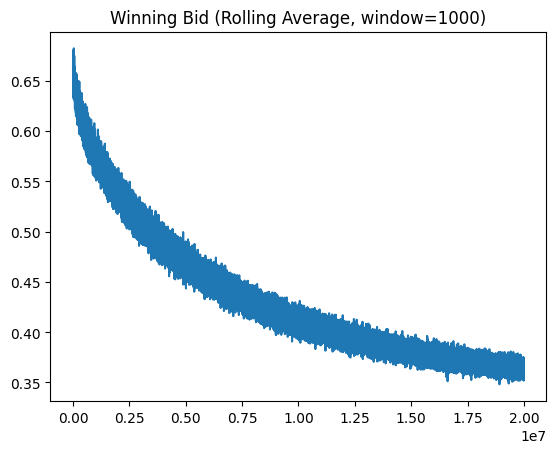

In [71]:
window = 1000
rolling_avg = df_fpa_bm['winning_bid'].rolling(window).mean()
plt.plot(range(T), rolling_avg)
plt.title(f'Winning Bid (Rolling Average, window={window})')

Text(0.5, 1.0, 'External Regret')

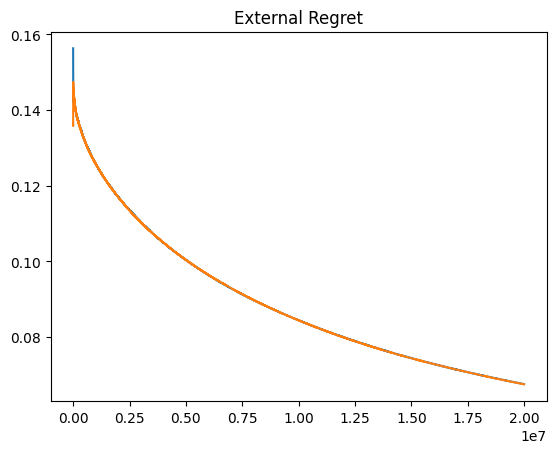

In [73]:
start = 1000
plt.plot(range(T-start), df_fpa_bm['external_regret1'][start:], label="External regret of bidder 1")
plt.plot(range(T-start), df_fpa_bm['external_regret2'][start:], label="External regret of bidder 2")
plt.title(f'External Regret')

Text(0.5, 1.0, 'Swap Regret')

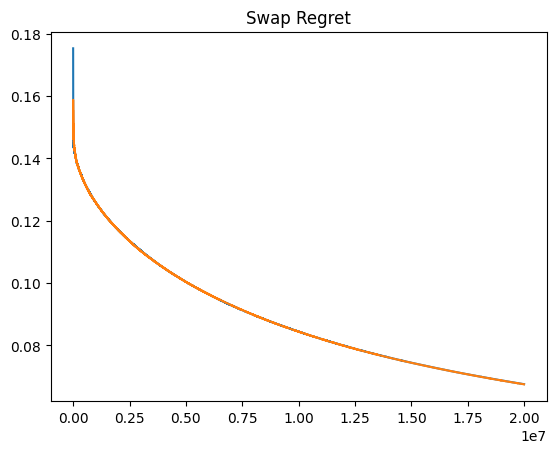

In [74]:
start = 1000
plt.plot(range(T-start), df_fpa_bm['swap_regret1'][start:], label="Swap regret of bidder 1")
plt.plot(range(T-start), df_fpa_bm['swap_regret2'][start:], label="Swap regret of bidder 2")
plt.title(f'Swap Regret')

# SPA No-Swap Learners

Text(0.5, 1.0, 'Winning Bid (Rolling Average, window=10000)')

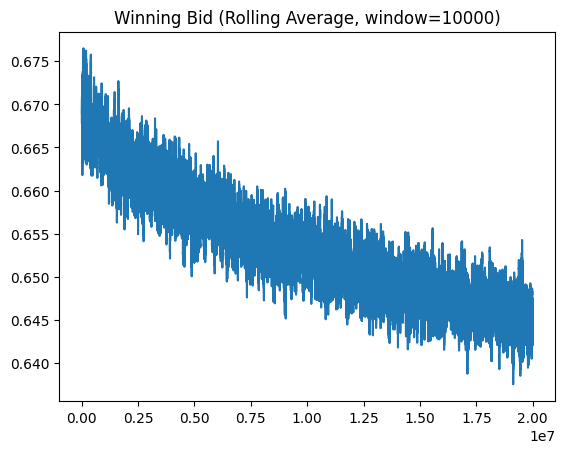

In [125]:
window = 10000
rolling_avg = df_spa_bm['winning_bid'].rolling(window).mean()
plt.plot(range(20000000), rolling_avg)
plt.title(f'Winning Bid (Rolling Average, window={window})')

Text(0.5, 1.0, 'External Regret')

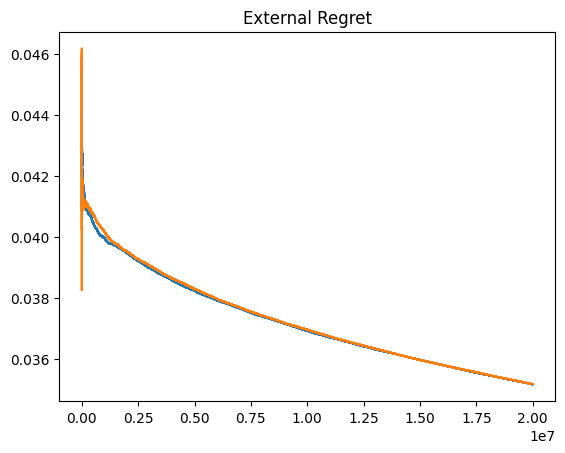

In [76]:
start = 1000
plt.plot(range(T-start), df_spa_bm['external_regret1'][start:], label="External regret of bidder 1")
plt.plot(range(T-start), df_spa_bm['external_regret2'][start:], label="External regret of bidder 2")
plt.title(f'External Regret')

Text(0.5, 1.0, 'Swap Regret')

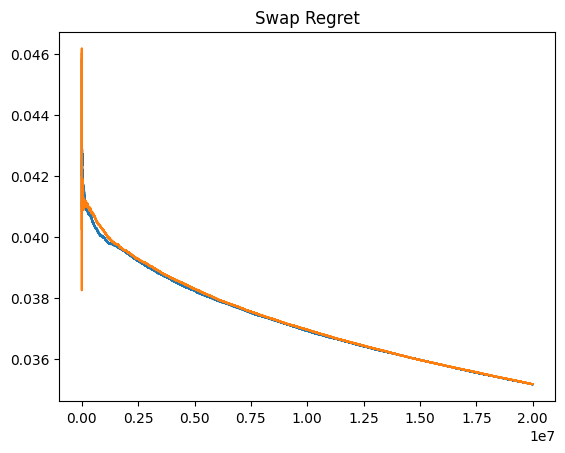

In [77]:
start = 1000
plt.plot(range(T-start), df_spa_bm['swap_regret1'][start:], label="Swap regret of bidder 1")
plt.plot(range(T-start), df_spa_bm['swap_regret2'][start:], label="Swap regret of bidder 2")
plt.title(f'Swap Regret')

## Winning bid distribution: FPA vs SPA

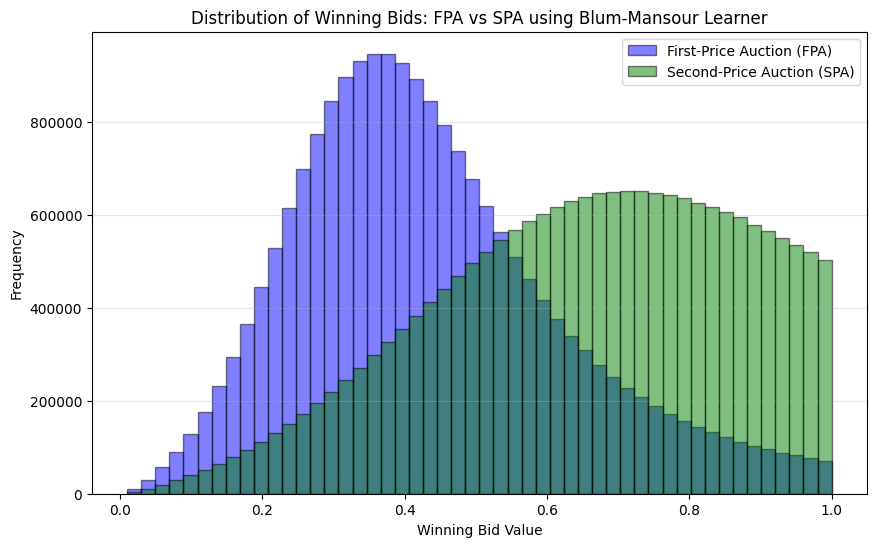

In [78]:
plt.figure(figsize=(10, 6))

# Plot FPA winning bids
plt.hist(df_fpa_bm['winning_bid'], bins=50, alpha=0.5, label='First-Price Auction (FPA)', color='blue', edgecolor='black')

# Plot SPA winning bids
plt.hist(df_spa_bm['winning_bid'], bins=50, alpha=0.5, label='Second-Price Auction (SPA)', color='green', edgecolor='black')

plt.title('Distribution of Winning Bids: FPA vs SPA using Blum-Mansour Learner')
plt.xlabel('Winning Bid Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

In [81]:
df_fpa_bm

,round,winner,winning_bid,payment,bid1,bid2,external_regret1,external_regret2,swap_regret1,swap_regret2
0,1,Bidder 1,0.27,0.27,0.27,0.22,0.040000,0.220000,0.040000,0.220000
1,2,Bidder 2,0.59,0.59,0.56,0.59,0.020000,0.155000,0.020000,0.155000
2,3,Bidder 1,0.85,0.85,0.85,0.76,0.130000,0.103333,0.130000,0.103333
3,4,Bidder 2,0.20,0.20,0.09,0.20,0.165000,0.057500,0.170000,0.102500
4,5,Bidder 2,0.77,0.77,0.25,0.77,0.132000,0.144000,0.136000,0.184000
...,...,...,...,...,...,...,...,...,...,...
19999995,19999996,Bidder 2,0.32,0.32,0.20,0.32,0.067554,0.067504,0.067565,0.067516
19999996,19999997,Bidder 2,0.37,0.37,0.31,0.37,0.067554,0.067504,0.067565,0.067516
19999997,19999998,Bidder 2,0.54,0.54,0.48,0.54,0.067554,0.067504,0.067565,0.067516
19999998,19999999,Bidder 1,0.35,0.35,0.35,0.09,0.067554,0.067504,0.067565,0.067516


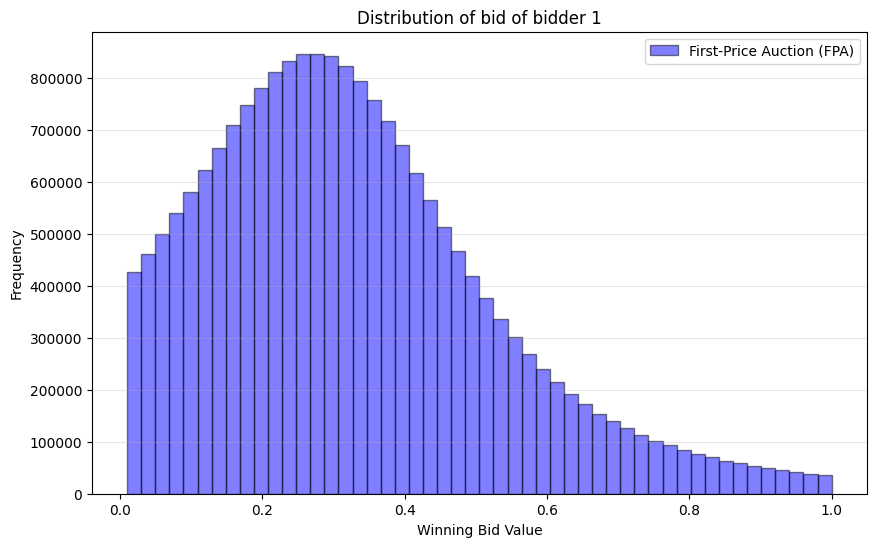

In [83]:
plt.figure(figsize=(10, 6))

# Plot FPA winning bids
plt.hist(df_fpa_bm['bid1'], bins=50, alpha=0.5, label='First-Price Auction (FPA)', color='blue', edgecolor='black')

# Plot SPA winning bids
# plt.hist(df_spa_bm['winning_bid'], bins=50, alpha=0.5, label='Second-Price Auction (SPA)', color='green', edgecolor='black')

plt.title('Distribution of bid of bidder 1')
plt.xlabel('Winning Bid Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

C:\Users\poom_pojtanut\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


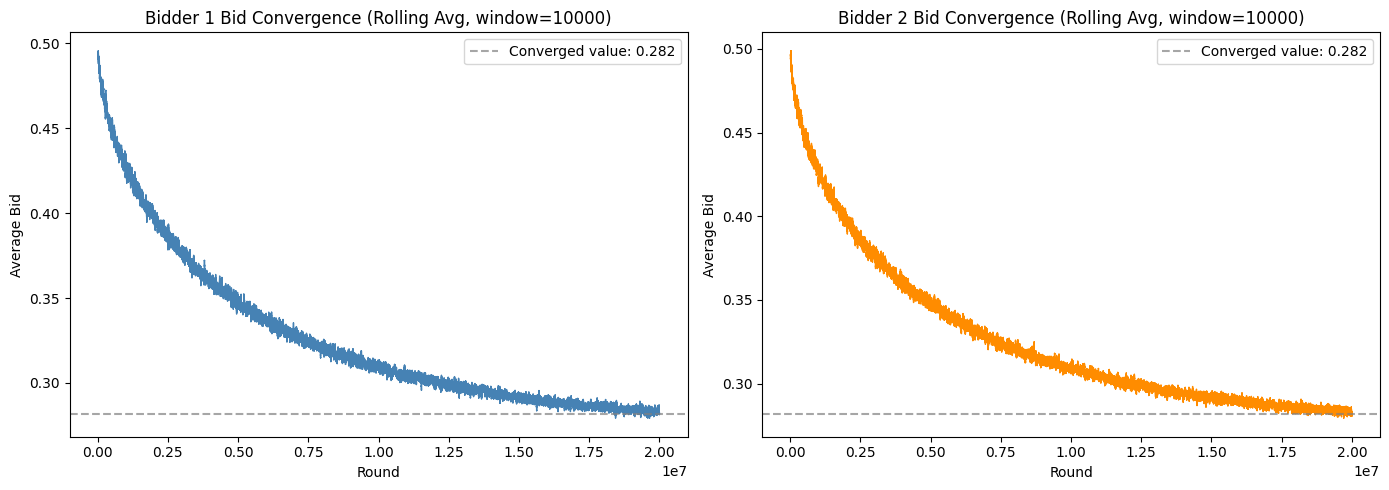

In [85]:
window = 10000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, bid_col, label, color in zip(
    axes,
    ['bid1', 'bid2'],
    ['Bidder 1', 'Bidder 2'],
    ['steelblue', 'darkorange']
):
    rolling = df_fpa_bm[bid_col].rolling(window=window).mean()
    ax.plot(df_fpa_bm['round'], rolling, color=color, linewidth=1)
    ax.set_title(f'{label} Bid Convergence (Rolling Avg, window={window})')
    ax.set_xlabel('Round')
    ax.set_ylabel('Average Bid')
    ax.axhline(rolling.iloc[-1], linestyle='--', color='gray', alpha=0.7,
               label=f'Converged value: {rolling.iloc[-1]:.3f}')
    ax.legend()

plt.tight_layout()
plt.show()

# FPA No-External-Regret

In [50]:
V = 100                  
v1 = 50 / V              
v2 = 50 / V      

T = 10000000
every = T / 20
etas = [0.1 / np.sqrt(t) for t in range(1, T + 1)]

df_fpa = simulate_auction(
    learning_rates=etas, 
    v1=v1, v2=v2, V=V, 
    auction_type='first', 
    algo1='MWU', 
    algo2='MWU', 
    every=every)

Round 0
Round 500000
Round 1000000
Round 1500000
Round 2000000
Round 2500000
Round 3000000
Round 3500000
Round 4000000
Round 4500000
Round 5000000
Round 5500000
Round 6000000
Round 6500000
Round 7000000
Round 7500000
Round 8000000
Round 8500000
Round 9000000
Round 9500000


Text(0.5, 1.0, 'Winning Bid of MWU on FPA')

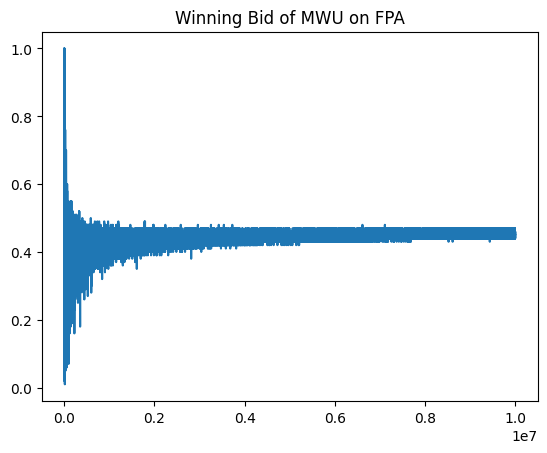

In [51]:
plt.plot(range(T), df_fpa['winning_bid'])
plt.title(f'Winning Bid of MWU on FPA')

Text(0.5, 1.0, 'External Regret')

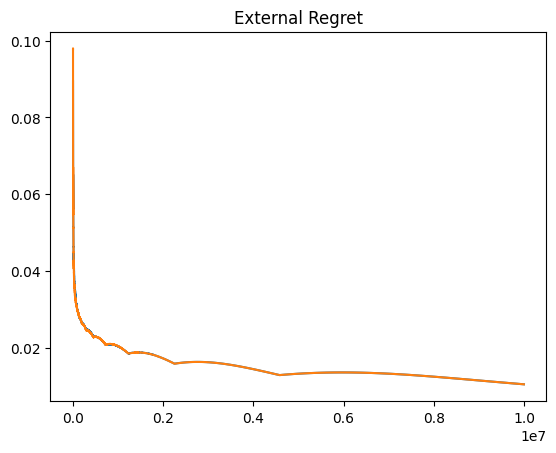

In [53]:
start = 1000
plt.plot(range(T-start), df_fpa['external_regret1'][start:], label="External regret of bidder 1")
plt.plot(range(T-start), df_fpa['external_regret2'][start:], label="External regret of bidder 2")
plt.title(f'External Regret')

Text(0.5, 1.0, 'Swap Regret')

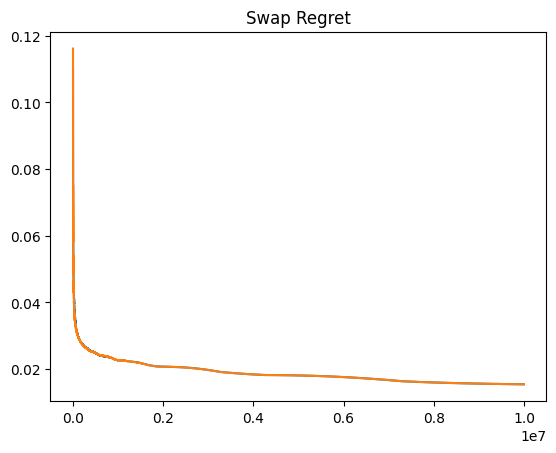

In [54]:
start = 1000
plt.plot(range(T-start), df_fpa['swap_regret1'][start:], label="Swap regret of bidder 1")
plt.plot(range(T-start), df_fpa['swap_regret2'][start:], label="Swap regret of bidder 2")
plt.title(f'Swap Regret')

# SPA No-External-Regret

In [55]:
V = 100                  
v1 = 50 / V              
v2 = 50 / V      

T = 10000000
every = T / 20
etas = [0.1 / np.sqrt(t) for t in range(1, T + 1)]

df_spa = simulate_auction(
    learning_rates=etas, 
    v1=v1, v2=v2, V=V, 
    auction_type='second', 
    algo1='MWU', 
    algo2='MWU', 
    every=every)

Round 0
Round 500000
Round 1000000
Round 1500000
Round 2000000
Round 2500000
Round 3000000
Round 3500000
Round 4000000
Round 4500000
Round 5000000
Round 5500000
Round 6000000
Round 6500000
Round 7000000
Round 7500000
Round 8000000
Round 8500000
Round 9000000
Round 9500000


Text(0.5, 1.0, 'Winning Bid of MWU on SPA')

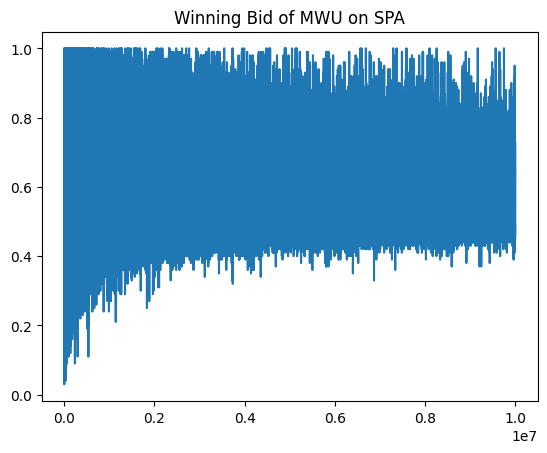

In [123]:
plt.plot(range(T), df_spa['winning_bid'])
plt.title(f'Winning Bid of MWU on SPA')

Text(0.5, 1.0, 'External Regret')

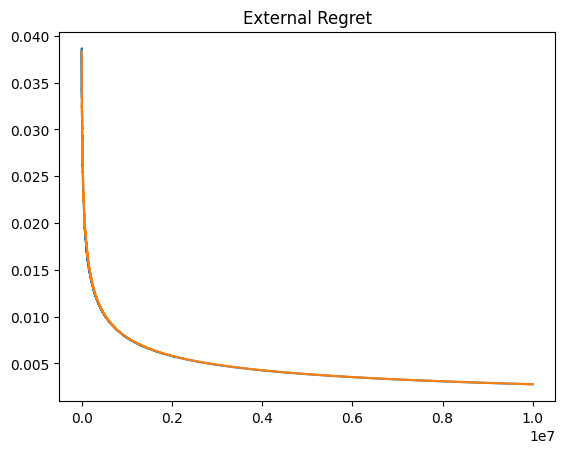

In [58]:
start = 1000
plt.plot(range(T-start), df_spa['external_regret1'][start:], label="External regret of bidder 1")
plt.plot(range(T-start), df_spa['external_regret2'][start:], label="External regret of bidder 2")
plt.title(f'External Regret')

Text(0.5, 1.0, 'Swap Regret')

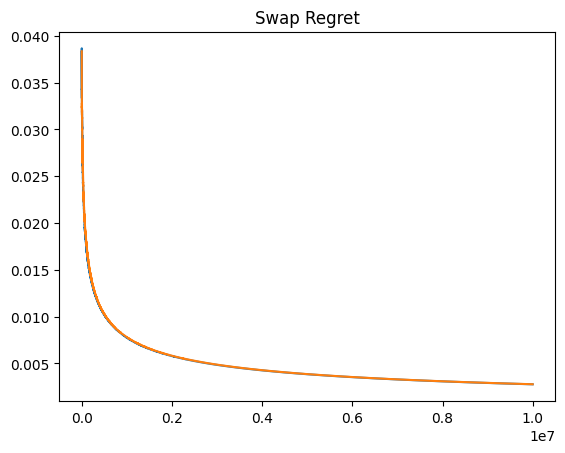

In [59]:
start = 1000
plt.plot(range(T-start), df_spa['swap_regret1'][start:], label="Swap regret of bidder 1")
plt.plot(range(T-start), df_spa['swap_regret2'][start:], label="Swap regret of bidder 2")
plt.title(f'Swap Regret')

## Winning bids distribution: FPA vs SPA

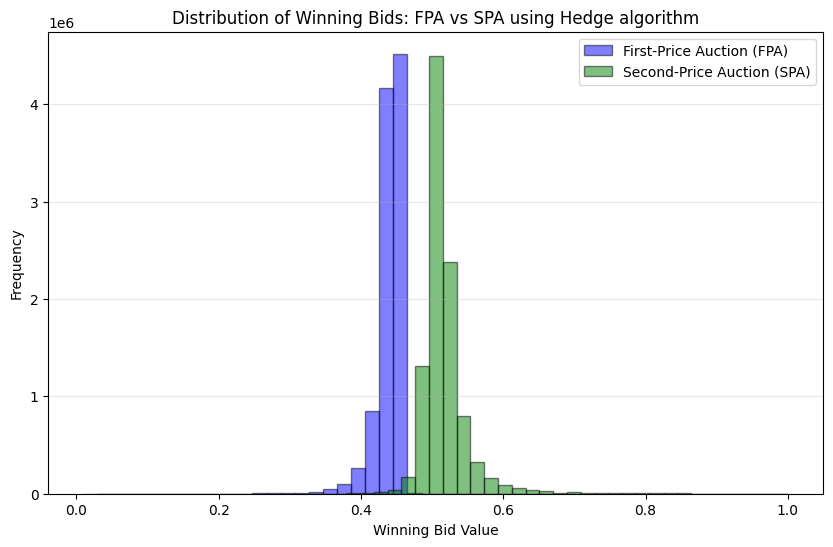

In [64]:
plt.figure(figsize=(10, 6))

# Plot FPA winning bids
plt.hist(df_fpa['winning_bid'], bins=50, alpha=0.5, label='First-Price Auction (FPA)', color='blue', edgecolor='black')

# Plot SPA winning bids
plt.hist(df_spa['winning_bid'], bins=50, alpha=0.5, label='Second-Price Auction (SPA)', color='green', edgecolor='black')

plt.title('Distribution of Winning Bids: FPA vs SPA using Hedge algorithm')
plt.xlabel('Winning Bid Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

# SPA $V_1=1, V_2=0.5$

In [110]:
V = 100                  
v1 = V / V              
v2 = 50 / V      

T = 10000000
every = T / 20
etas = [0.1 / np.sqrt(t) for t in range(1, T + 1)]

df_spa_1_05 = simulate_auction(
    learning_rates=etas, 
    v1=v1, v2=v2, V=V, 
    auction_type='second', 
    algo1='MWU', 
    algo2='MWU', 
    every=every)

Round 0
Round 500000
Round 1000000
Round 1500000
Round 2000000
Round 2500000
Round 3000000
Round 3500000
Round 4000000
Round 4500000
Round 5000000
Round 5500000
Round 6000000
Round 6500000
Round 7000000
Round 7500000
Round 8000000
Round 8500000
Round 9000000
Round 9500000


Text(0.5, 1.0, 'Winning Bid of MWU on SPA')

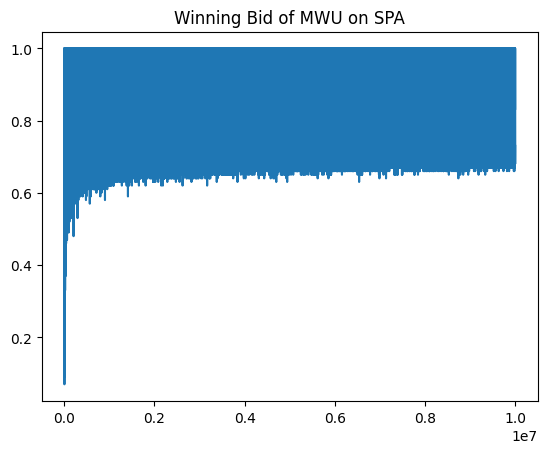

In [111]:
plt.plot(range(T), df_spa_1_05['winning_bid'])
plt.title(f'Winning Bid of MWU on SPA')

# FPA $V_1=1, V_2=0.5$

In [114]:
V = 100                  
v1 = V / V              
v2 = 50 / V      

T = 10000000
every = T / 20
etas = [0.1 / np.sqrt(t) for t in range(1, T + 1)]

df_fpa_1_05 = simulate_auction(
    learning_rates=etas, 
    v1=v1, v2=v2, V=V, 
    auction_type='first', 
    algo1='MWU', 
    algo2='MWU', 
    every=every)

Round 0
Round 500000
Round 1000000
Round 1500000
Round 2000000
Round 2500000
Round 3000000
Round 3500000
Round 4000000
Round 4500000
Round 5000000
Round 5500000
Round 6000000
Round 6500000
Round 7000000
Round 7500000
Round 8000000
Round 8500000
Round 9000000
Round 9500000


Text(0.5, 1.0, 'Winning Bid of MWU on SPA')

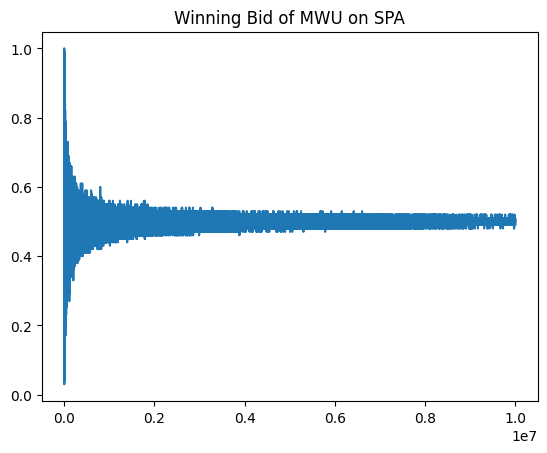

In [115]:
plt.plot(range(T), df_fpa_1_05['winning_bid'])
plt.title(f'Winning Bid of MWU on SPA')

# SPA $V_1=1, V_2=0.1$

In [109]:
V = 100                  
v1 = V / V              
v2 = 10 / V      

T = 10000000
every = T / 20
etas = [0.1 / np.sqrt(t) for t in range(1, T + 1)]

df_spa_1_01 = simulate_auction(
    learning_rates=etas, 
    v1=v1, v2=v2, V=V, 
    auction_type='second', 
    algo1='MWU', 
    algo2='MWU', 
    every=every)

Round 0
Round 500000
Round 1000000
Round 1500000
Round 2000000
Round 2500000
Round 3000000
Round 3500000
Round 4000000
Round 4500000
Round 5000000
Round 5500000
Round 6000000
Round 6500000
Round 7000000
Round 7500000
Round 8000000
Round 8500000
Round 9000000
Round 9500000


Text(0.5, 1.0, 'Winning Bid of MWU on SPA')

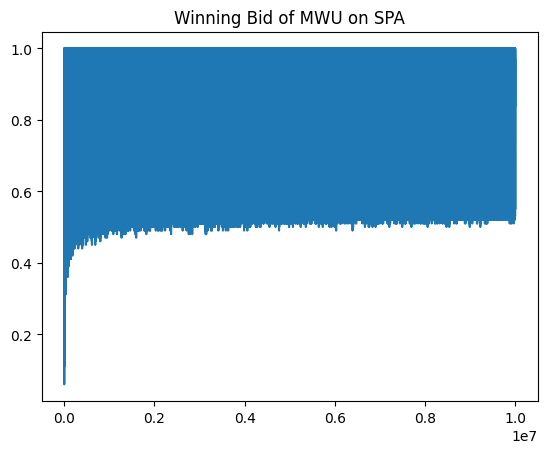

In [112]:
plt.plot(range(T), df_spa_1_01['winning_bid'])
plt.title(f'Winning Bid of MWU on SPA')

# FPA $V_1=1, V_2=0.1$

In [118]:
V = 100                  
v1 = V / V              
v2 = 10 / V      

T = 10000000
every = T / 20
etas = [0.1 / np.sqrt(t) for t in range(1, T + 1)]

df_fpa_1_01 = simulate_auction(
    learning_rates=etas, 
    v1=v1, v2=v2, V=V, 
    auction_type='first', 
    algo1='MWU', 
    algo2='MWU', 
    every=every)

Round 0
Round 500000
Round 1000000
Round 1500000
Round 2000000
Round 2500000
Round 3000000
Round 3500000
Round 4000000
Round 4500000
Round 5000000
Round 5500000
Round 6000000
Round 6500000
Round 7000000
Round 7500000
Round 8000000
Round 8500000
Round 9000000
Round 9500000


# FPA diff lr

In [121]:
V = 100                  
v1 = 50 / V              
v2 = 50 / V      

T = 10000000
every = T / 20
etas = [0.1 / np.sqrt(t) for t in range(1, T + 1)]
etas2 = [1 / np.sqrt(t) for t in range(1, T + 1)]

df_fpa_05_05_lr = simulate_auction(
    learning_rates=etas, 
    learning_rates_2=etas2, 
    v1=v1, v2=v2, V=V, 
    auction_type='first', 
    algo1='MWU', 
    algo2='MWU', 
    every=every)

Round 0
Round 500000
Round 1000000
Round 1500000
Round 2000000
Round 2500000
Round 3000000
Round 3500000
Round 4000000
Round 4500000
Round 5000000
Round 5500000
Round 6000000
Round 6500000
Round 7000000
Round 7500000
Round 8000000
Round 8500000
Round 9000000
Round 9500000


# SPA diff lr

In [122]:
V = 100                  
v1 = 50 / V              
v2 = 50 / V      

T = 10000000
every = T / 20
etas = [0.1 / np.sqrt(t) for t in range(1, T + 1)]
etas2 = [1 / np.sqrt(t) for t in range(1, T + 1)]

df_spa_05_05_lr = simulate_auction(
    learning_rates=etas, 
    learning_rates_2=etas2, 
    v1=v1, v2=v2, V=V, 
    auction_type='second', 
    algo1='MWU', 
    algo2='MWU', 
    every=every)

Round 0
Round 500000
Round 1000000
Round 1500000
Round 2000000
Round 2500000
Round 3000000
Round 3500000
Round 4000000
Round 4500000
Round 5000000
Round 5500000
Round 6000000
Round 6500000
Round 7000000
Round 7500000
Round 8000000
Round 8500000
Round 9000000
Round 9500000


Text(0.5, 1.0, 'Winning Bid of MWU on SPA')

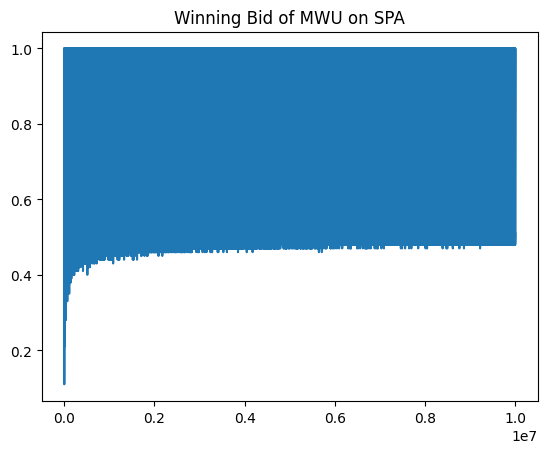

In [126]:
plt.plot(range(T), df_spa_05_05_lr['winning_bid'])
plt.title(f'Winning Bid of MWU on SPA')

Text(0.5, 1.0, 'Winning Bid of MWU on SPA')

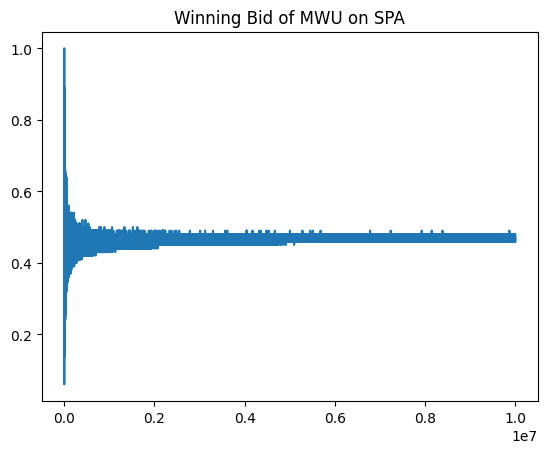

In [127]:
plt.plot(range(T), df_fpa_05_05_lr['winning_bid'])
plt.title(f'Winning Bid of MWU on SPA')

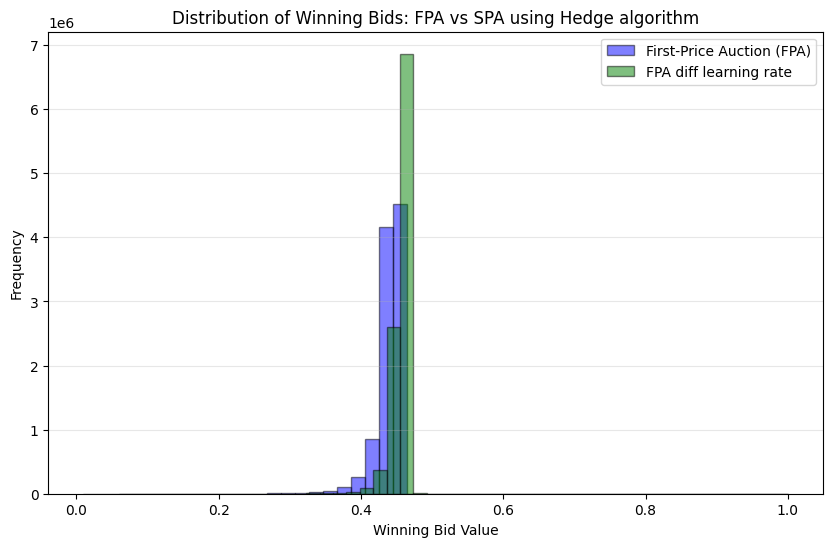

In [128]:
plt.figure(figsize=(10, 6))

# Plot FPA winning bids
plt.hist(df_fpa['winning_bid'], bins=50, alpha=0.5, label='First-Price Auction (FPA)', color='blue', edgecolor='black')

# Plot SPA winning bids
plt.hist(df_fpa_05_05_lr['winning_bid'], bins=50, alpha=0.5, label='FPA diff learning rate', color='green', edgecolor='black')

plt.title('Distribution of Winning Bids: FPA vs SPA using Hedge algorithm')
plt.xlabel('Winning Bid Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

# Multiple runs

In [99]:
def simulate_auction(v1, v2, V, learning_rates, auction_type='first', algo1='MWU', algo2='MWU'):
    bids = np.array([i / V for i in range(1, V + 1)])
    num_bids = len(bids)

    agent1 = MWUAgent(num_bids) if algo1 == 'MWU' else NoSwapRegretAgent(num_bids)
    agent2 = MWUAgent(num_bids) if algo2 == 'MWU' else NoSwapRegretAgent(num_bids)

    history = {
        'round': [], 'bid1': [], 'bid2': [],
        'winning_bid': [],  # added
        'strategy1': [],
        'strategy2': []
    }

    for t, eta in enumerate(learning_rates):
        p1 = agent1.get_strategy()
        p2 = agent2.get_strategy()

        b1 = np.random.choice(bids, p=p1)
        b2 = np.random.choice(bids, p=p2)

        if b1 > b2:
            winner, winning_bid, payment = 1, b1, b1 if auction_type == 'first' else b2
        elif b2 > b1:
            winner, winning_bid, payment = 2, b2, b2 if auction_type == 'first' else b1
        else:
            winner = np.random.choice([1, 2])
            winning_bid, payment = b1, b1 if auction_type == 'first' else b2

        history['round'].append(t + 1)
        history['bid1'].append(b1)
        history['bid2'].append(b2)
        history['winning_bid'].append(winning_bid)  # added
        history['strategy1'].append(p1.copy())
        history['strategy2'].append(p2.copy())

        u1 = np.zeros(num_bids)
        u2 = np.zeros(num_bids)
        for i, b in enumerate(bids):
            if b > b2:
                u1[i] = v1 - (b if auction_type == 'first' else b2)
            elif b == b2:
                u1[i] = 0.5 * (v1 - (b if auction_type == 'first' else b2))
            if b > b1:
                u2[i] = v2 - (b if auction_type == 'first' else b1)
            elif b == b1:
                u2[i] = 0.5 * (v2 - (b if auction_type == 'first' else b1))

        agent1.update(u1, eta)
        agent2.update(u2, eta)

    return pd.DataFrame(history)


def plot_convergence(all_dfs, V, window=200, bids_to_plot=None, n_top=5):
    bids = np.array([i / V for i in range(1, V + 1)])

    if bids_to_plot is None:
        last_frac = int(len(all_dfs[0]) * 0.1)
        avg_strat1 = np.mean([
            np.array(df['strategy1'].tolist())[-last_frac:].mean(axis=0)
            for df in all_dfs
        ], axis=0)
        top_indices = np.argsort(avg_strat1)[-n_top:][::-1]
        bids_to_plot = bids[top_indices]

    bid_labels = [f'bid {int(round(b * V))}' for b in bids_to_plot]
    bid_indices = [np.searchsorted(bids, b) for b in bids_to_plot]
    colors = plt.cm.tab10(np.linspace(0, 0.6, len(bids_to_plot)))
    linestyles = ['-', ':', '-.', '--', (0, (3, 1, 1, 1))]
    rounds = all_dfs[0]['round'].values

    # 3 rows now: freq, strategy, winning bid
    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    fig.suptitle('Bid Frequency, Mixed Strategy, and Winning Bid Convergence', fontsize=14)

    for player_idx, (player, bid_col, strat_col) in enumerate(
        [('Player 1', 'bid1', 'strategy1'), ('Player 2', 'bid2', 'strategy2')]
    ):
        ax_freq  = axes[0][player_idx]
        ax_strat = axes[1][player_idx]

        freq_arrays  = {i: [] for i in bid_indices}
        strat_arrays = {i: [] for i in bid_indices}

        for df in all_dfs:
            for b_val, b_idx in zip(bids_to_plot, bid_indices):
                one_hot = (df[bid_col].values == b_val).astype(float)
                rolled  = pd.Series(one_hot).rolling(window=window, min_periods=1).mean().values
                freq_arrays[b_idx].append(rolled)

                strat_col_vals = np.array(df[strat_col].tolist())
                strat_arrays[b_idx].append(strat_col_vals[:, b_idx])

        for b_val, b_idx, label, color, ls in zip(
            bids_to_plot, bid_indices, bid_labels, colors, linestyles
        ):
            freq_mat = np.array(freq_arrays[b_idx])
            mean_f, std_f = freq_mat.mean(axis=0), freq_mat.std(axis=0)
            ax_freq.plot(rounds, mean_f, label=label, color=color, linestyle=ls)
            ax_freq.fill_between(rounds, mean_f - std_f, mean_f + std_f, alpha=0.2, color=color)

            strat_mat = np.array(strat_arrays[b_idx])
            mean_s, std_s = strat_mat.mean(axis=0), strat_mat.std(axis=0)
            ax_strat.plot(rounds, mean_s, label=label, color=color, linestyle=ls)
            ax_strat.fill_between(rounds, mean_s - std_s, mean_s + std_s, alpha=0.2, color=color)

        for ax, title, ylabel in [
            (ax_freq,  f"{player}'s bid frequency",        'frequency'),
            (ax_strat, f"{player}'s mixed strategy $x_t$", 'probability'),
        ]:
            ax.set_title(title)
            ax.set_xlabel('time $t$')
            ax.set_ylabel(ylabel)
            ax.set_ylim(-0.05, 1.05)
            ax.legend(fontsize=8)

    # ── Bottom row: average winning bid (same for both players, shown side by side) ──
    winning_bid_mat = np.array([
        pd.Series(df['winning_bid']).rolling(window=window, min_periods=1).mean().values
        for df in all_dfs
    ])  # (n_seeds, T)
    mean_w = winning_bid_mat.mean(axis=0)
    std_w  = winning_bid_mat.std(axis=0)

    for ax in axes[2]:
        ax.plot(rounds, mean_w, color='purple', linewidth=1.5, label='Avg winning bid')
        ax.fill_between(rounds, mean_w - std_w, mean_w + std_w, alpha=0.2, color='purple')
        ax.axhline(mean_w[-1], linestyle='--', color='gray', alpha=0.7,
                   label=f'Converged: {mean_w[-1]:.3f}')
        ax.set_title('Average Winning Bid over Time')
        ax.set_xlabel('time $t$')
        ax.set_ylabel('winning bid')
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

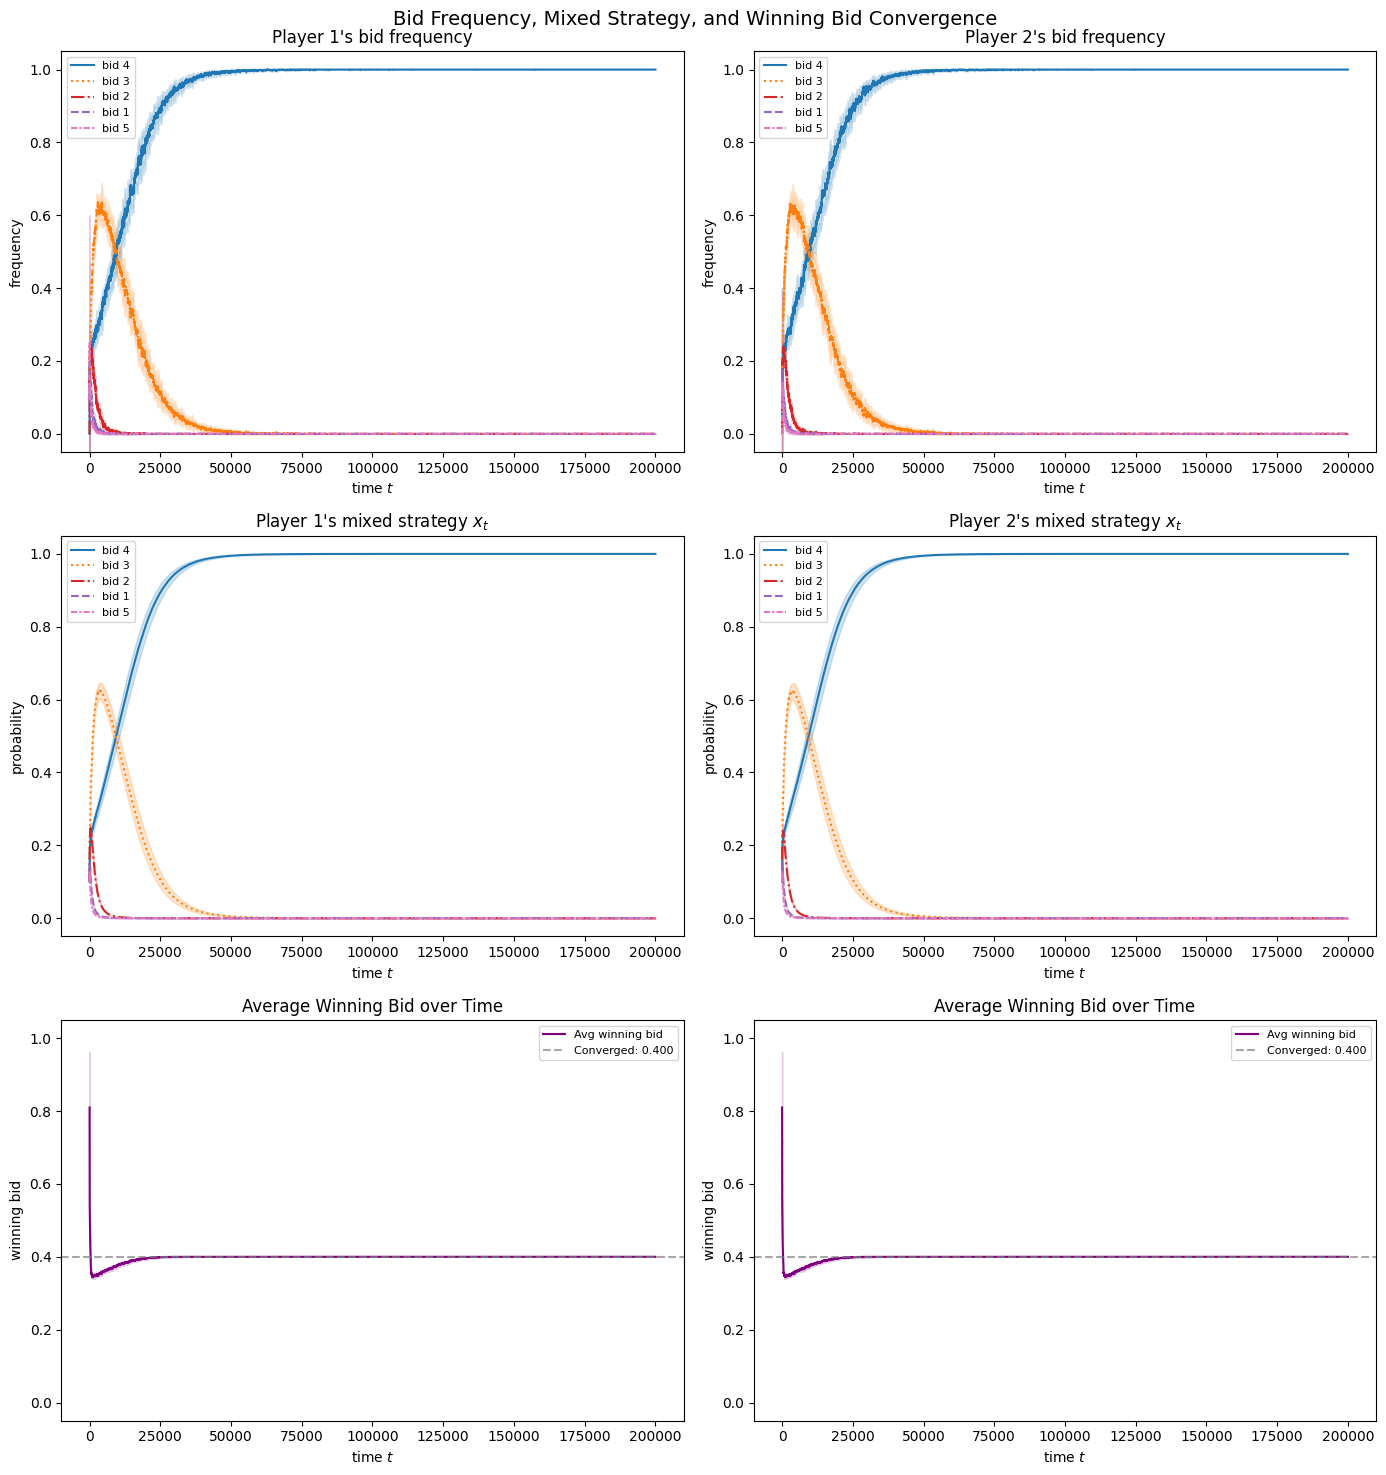

In [100]:
v1, v2   = 0.5, 0.5
V        = 10
T        = 200000
eta_c    = 0.5
learning_rates = [eta_c / np.sqrt(t + 1) for t in range(T)]

all_dfs = run_multiple_seeds(
    n_seeds=10, v1=v1, v2=v2, V=V,
    learning_rates=learning_rates,
    auction_type='first', algo1='MWU', algo2='MWU'
)

plot_convergence(all_dfs, V=V, window=300)

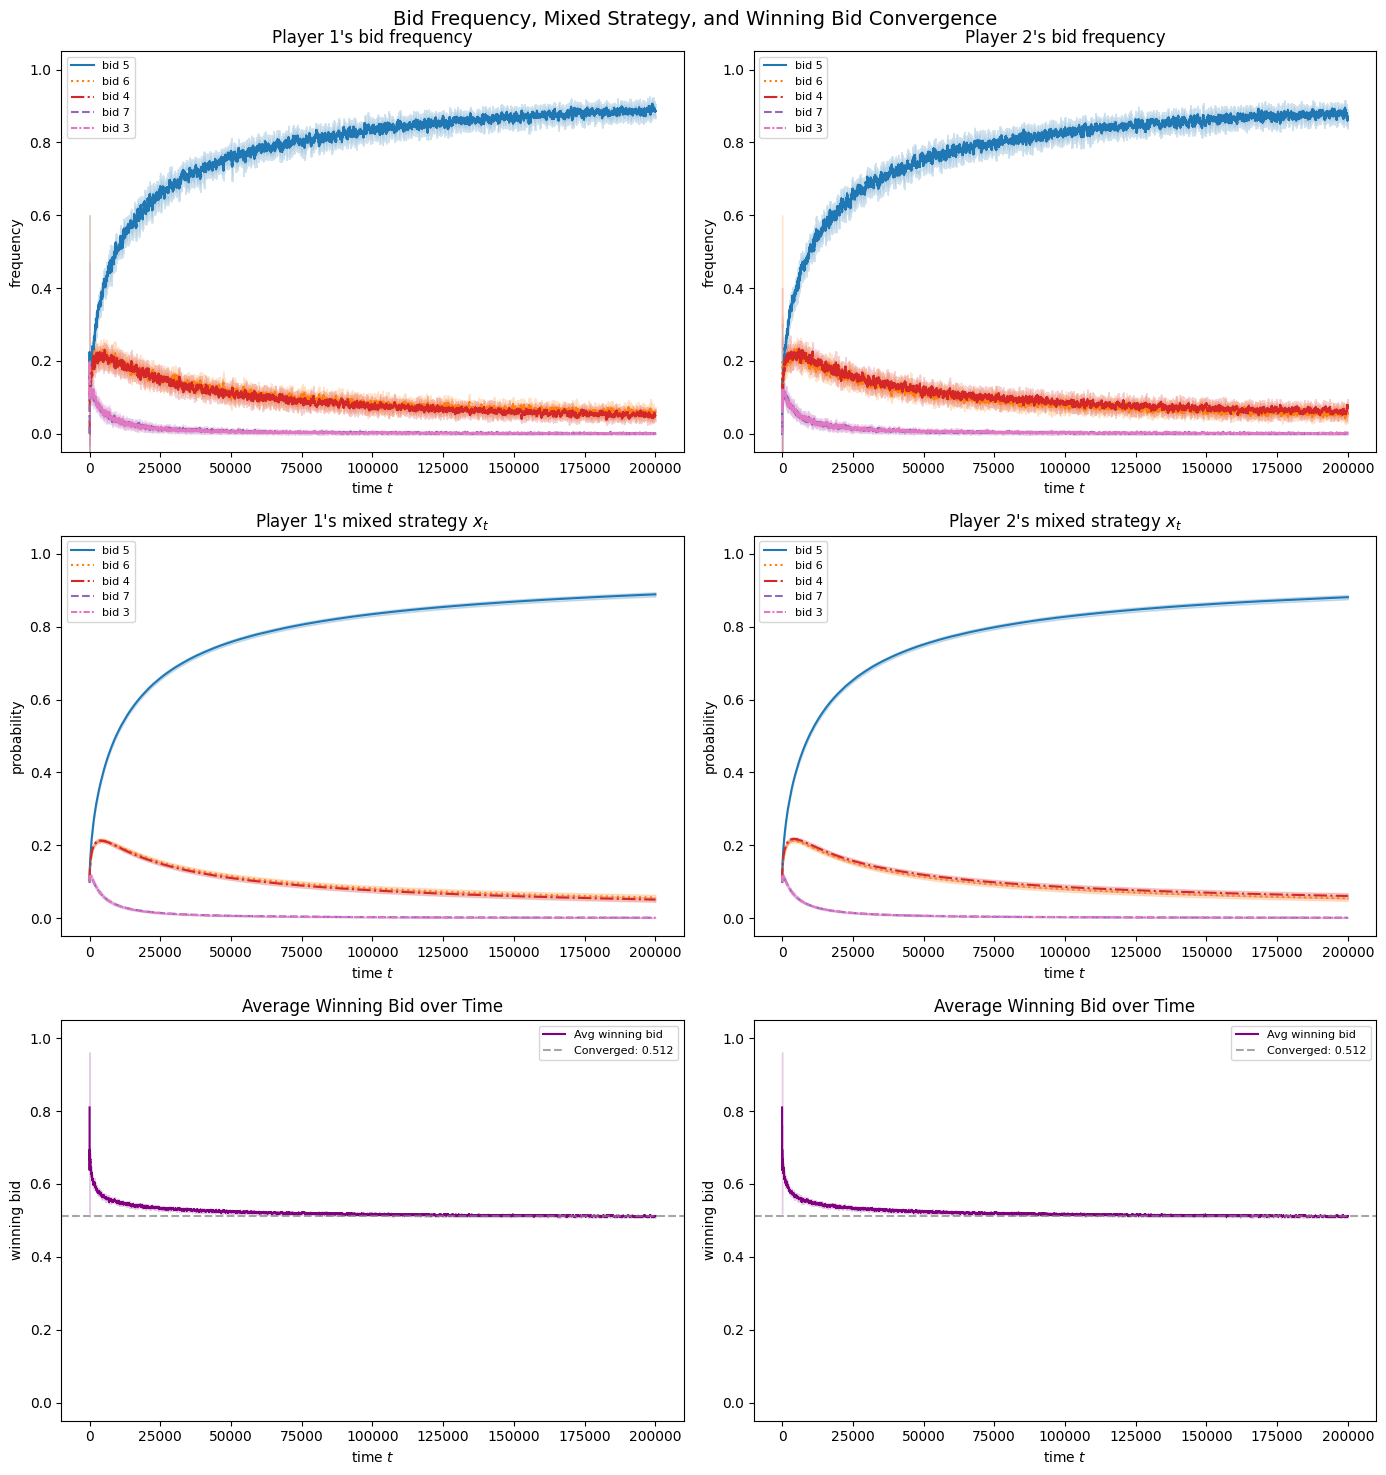

In [101]:
v1, v2   = 0.5, 0.5
V        = 10
T        = 200000
eta_c    = 0.5
learning_rates = [eta_c / np.sqrt(t + 1) for t in range(T)]

all_dfs = run_multiple_seeds(
    n_seeds=10, v1=v1, v2=v2, V=V,
    learning_rates=learning_rates,
    auction_type='second', algo1='MWU', algo2='MWU'
)

plot_convergence(all_dfs, V=V, window=300)